## **Data**

This dataset contains transaction data from SaaS company selling sales and marketing software to other companies (B2B). In the dataset, each row represents a single transaction/order (9,994 transactions), and the columns include:

## **Column Description**

**Here is the Original Dataset:**

| **Columns Name** | **Column Description**                                   |
| ---------------- | -------------------------------------------------------- |
| **Row ID**       | A unique identifier for each transaction.                |
| **Order ID**     | A unique identifier for each order.                      |
| **Order Date**   | The date when the order was placed.                      |
| **Date Key**     | A numerical representation of the order date (YYYYMMDD). |
| **Contact Name** | The name of the person who placed the order.             |
| **Country**      | The country where the order was placed.                  |
| **City**         | The city where the order was placed.                     |
| **Region**       | The region where the order was placed.                   |
| **Subregion**    | The subregion where the order was placed.                |
| **Customer**     | The name of the company that placed the order.           |
| **Customer ID**  | A unique identifier for each customer.                   |
| **Industry**     | The industry the customer belongs to.                    |
| **Segment**      | The customer segment (SMB, Strategic, Enterprise, etc.). |
| **Product**      | The product was ordered.                                 |
| **License**      | The license key for the product                          |
| **Sales**        | The total sales amount for the transaction.              |
| **Quantity**     | The total number of items in the transaction             |
| **Discount**     | The discount applied to the transaction.                 |
| **Profit**       | The profit from the transaction.                         |


**Import Modules and Load Dataset**

In [926]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: C:\Users\benjamin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# For Geographical Analysis
import folium
import geopy
from geopy.geocoders import Nominatim
import requests

import warnings
warnings.filterwarnings('ignore')

In [94]:
df = pd.read_csv('SaaS-Sales.csv')

# 1. Data Understanding and Data Cleaning

## A. Data Understanding

In [95]:
# Check Data Shape, Data Info, and Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [96]:
df.duplicated().sum()

0

From the output above, we can see most of the columns is having the right data types and there are **no missing values** nor **duplicate values** as all the column count is the same as the column row shape, but we will change some of the column data type into the appropriate data type

**We will do some changes to the dataset**

1. `Row ID` : This column already assigned with the right datatype (int) and will be set to be the index
2. `Order Date` : This column will be parsed to datetime type
3. `Customer ID` : Although it contains number only, this column should be assigned to object type data
4. `Date Key` : This column will be **dropped** because its values is the same as `Order Date`, therefore it is a redundant data

**And we will add some numerical columns / feature to complete the dataset along with the information**
1. Monthly : Timestamp data with the monthly frequency
2. Total Cost : The total cost in the transaction
3. Unit Cost : The unit / item costs in the transaction
4. Unit Price : The unit / item price in the transaction *(before discount)*
5. Total Price : The total of unit / item price in the transaction *(before discount)*
6. Discount Price : The discounted price in the transaction (in $)

In [52]:
# Set 'Order ID' to be the index
df.set_index('Row ID', inplace = True)

# Parse 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Parse 'Customer ID' to object
df['Customer ID'] = df['Customer ID'].astype('object')

# Drop unused column (Date Key)
df.drop('Date Key', 
        axis = 1,
        inplace = True)

# Feature Engineering:
# Monthly
df['Monthly'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()
# Sorting Values by Date
df.sort_values(by = 'Order Date', inplace = True)

# Total Cost
df['Total Cost'] = df['Sales'] - df['Profit']

# Unit Cost
df['Unit Cost'] = df['Total Cost'] / df['Quantity']

# Unit Price
df['Unit Price'] = df['Sales'] / (df['Quantity'] * (1 - df['Discount']))

# Total Price
df['Total Price'] = df['Unit Price'] * df['Quantity']

# Discount Price
df['Discount Price'] = df['Discount'] * df['Total Price']

df.reset_index(drop = True, inplace = True)

col_order_1 = df.iloc[:,:13].columns.tolist()
col_order_2 = ['Monthly' ,'Unit Cost', 'Unit Price', 'Quantity','Total Cost', 'Total Price', 'Discount', 'Sales', 'Profit', 'Discount Price']


df = df.reindex(columns = col_order_1 + col_order_2)

display(df.head())
df.info()

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,...,Monthly,Unit Cost,Unit Price,Quantity,Total Cost,Total Price,Discount,Sales,Profit,Discount Price
0,APJ-2020-103800,2020-01-04,Brian Dickens,Japan,Tokyo,APJ,JAPN,Siemens,1043,Manufacturing,...,2020-01-01,5.4484,10.28,2,10.8968,20.56,0.2,16.448,5.5512,4.112
1,APJ-2020-112326,2020-01-05,Liam Churchill,Australia,Wollongong,APJ,ANZ,CVS Health,1026,Retail,...,2020-01-01,2.5041,4.91,3,7.5123,14.73,0.2,11.784,4.2717,2.946
2,APJ-2020-112326,2020-01-05,Liam Churchill,Australia,Wollongong,APJ,ANZ,CVS Health,1026,Retail,...,2020-01-01,112.5036,113.64,3,337.5108,340.92,0.2,272.736,-64.7748,68.184
3,APJ-2020-112326,2020-01-05,Liam Churchill,Australia,Wollongong,APJ,ANZ,CVS Health,1026,Retail,...,2020-01-01,4.5135,8.85,2,9.0270,17.70,0.8,3.540,-5.4870,14.160
4,EMEA-2020-141817,2020-01-06,Ella Springer,France,Paris,EMEA,EU-WEST,Mitsubishi,1050,Manufacturing,...,2020-01-01,4.8840,8.14,3,14.6520,24.42,0.2,19.536,4.8840,4.884


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   object        
 1   Order Date      9994 non-null   datetime64[ns]
 2   Contact Name    9994 non-null   object        
 3   Country         9994 non-null   object        
 4   City            9994 non-null   object        
 5   Region          9994 non-null   object        
 6   Subregion       9994 non-null   object        
 7   Customer        9994 non-null   object        
 8   Customer ID     9994 non-null   object        
 9   Industry        9994 non-null   object        
 10  Segment         9994 non-null   object        
 11  Product         9994 non-null   object        
 12  License         9994 non-null   object        
 13  Monthly         9994 non-null   datetime64[ns]
 14  Unit Cost       9994 non-null   float64       
 15  Unit

Descriptive Statistic

In [23]:
display(df.describe().round(2), df.describe(include = 'object'))

,Order Date,Monthly,Unit Cost,Unit Price,Quantity,Total Cost,Total Price,Discount,Sales,Profit,Discount Price
count,9994,9994,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,2022-05-01 00:07:12.259355648,2022-04-16 08:46:20.868521216,53.12,75.57,3.79,201.20,286.57,0.16,229.86,28.66,56.71
min,2020-01-04 00:00:00,2020-01-01 00:00:00,0.54,0.99,1.00,0.55,0.99,0.00,0.44,-6599.98,0.00
25%,2021-05-23 00:00:00,2021-05-01 00:00:00,3.47,6.48,2.00,12.69,21.36,0.00,17.28,1.73,0.00
50%,2022-06-27 00:00:00,2022-06-01 00:00:00,12.93,19.98,3.00,41.66,64.96,0.20,54.49,8.67,1.34
75%,2023-05-15 00:00:00,2023-05-01 00:00:00,54.52,76.98,5.00,182.23,251.91,0.20,209.94,29.36,24.00
max,2023-12-31 00:00:00,2023-12-01 00:00:00,4074.93,7546.16,14.00,24449.56,45276.96,0.80,22638.48,8399.98,22638.48
std,NaN,NaN,122.25,188.96,2.23,550.84,864.10,0.21,623.25,234.26,360.89


,Order ID,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,793,48,262,3,12,99,99,10,3,14,9994
top,EMEA-2023-100111,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,1080,Finance,SMB,ContactMatcher,730VUNTJF5
freq,14,37,2001,922,4219,2507,192,192,2127,5191,1842,1


From the output above, we can see

1. There are no missing values, we can see from the count row on both of the output that all the values count are 9994, it's the same as the column row shape

2. `Profit` column have a negative value as the minimum value (-6599,978), we can conclude that there are negative profits / loss

3. `Order ID` unique values isn't the same as the value count, we can conclude there is a repetition on the order from customer

4. `Contact Name` unique value count isn't the same as `Customer`, therefore we know that one customer have more than one `Contact Name`

---

We will split the dataset into two datasets, `numerical` datatypes and object/`categorical` datatypes, we do this to simplify our analysis further on the `numerical` and `categorical` type columns

In [48]:
numerical = df[df.select_dtypes(include=['int64', 'float64']).columns.tolist()]
categorical = df[df.select_dtypes(exclude=['int64', 'float64', 'datetime']).columns.tolist()]

display(categorical.head())
display(numerical.head())

,Order ID,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License
0,APJ-2020-103800,Brian Dickens,Japan,Tokyo,APJ,JAPN,Siemens,1043,Manufacturing,SMB,Support,730VUNTJF5
1,APJ-2020-112326,Liam Churchill,Australia,Wollongong,APJ,ANZ,CVS Health,1026,Retail,Enterprise,FinanceHub,XGQWR8K66V
2,APJ-2020-112326,Liam Churchill,Australia,Wollongong,APJ,ANZ,CVS Health,1026,Retail,Enterprise,Marketing Suite - Gold,54J2FWJY59
3,APJ-2020-112326,Liam Churchill,Australia,Wollongong,APJ,ANZ,CVS Health,1026,Retail,Enterprise,ContactMatcher,K3HDHHY5YG
4,EMEA-2020-141817,Ella Springer,France,Paris,EMEA,EU-WEST,Mitsubishi,1050,Manufacturing,SMB,ChatBot Plugin,PGSY1LZQ71


,Unit Cost,Unit Price,Quantity,Total Cost,Total Price,Discount,Sales,Profit,Discount Price
0,5.4484,10.28,2,10.8968,20.56,0.2,16.448,5.5512,4.112
1,2.5041,4.91,3,7.5123,14.73,0.2,11.784,4.2717,2.946
2,112.5036,113.64,3,337.5108,340.92,0.2,272.736,-64.7748,68.184
3,4.5135,8.85,2,9.0270,17.70,0.8,3.540,-5.4870,14.160
4,4.8840,8.14,3,14.6520,24.42,0.2,19.536,4.8840,4.884


**Outlier Check**

In this step, we will check the outliers using IQR (Interquartile Range) on each of `numerical` columns and see if there is any outliers on the data

In [25]:
# Check Outliers : IQR

outliers_info = []

for col in numerical.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    outlier = pd.DataFrame(df[col][(df[col] < lower_bound) | (df[col] > upper_bound)])
    
    outliers_info.append([int(round(lower_bound, 0)),
                          int(round(upper_bound, 0)),
                          len(outlier),
                          df[col].min(),
                          df[col].max()])

outliers_info = pd.DataFrame(outliers_info, 
                             columns = ['Lower Bound', 
                                       'Upper Bound',
                                       'Number of Outliers',
                                       'Min Value',
                                       'Max Value'],
                             index = numerical.columns)
outliers_info


,Lower Bound,Upper Bound,Number of Outliers,Min Value,Max Value
Unit Cost,-73,131,1157,0.5445,4074.9264
Unit Price,-99,183,1026,0.9900,7546.1600
Quantity,-2,10,170,1.0000,14.0000
Total Cost,-242,437,1228,0.5544,24449.5584
Total Price,-324,598,1201,0.9900,45276.9600
Discount,0,0,856,0.0000,0.8000
Sales,-272,499,1167,0.4440,22638.4800
Profit,-40,71,1881,-6599.9780,8399.9760
Discount Price,-36,60,1602,0.0000,22638.4800


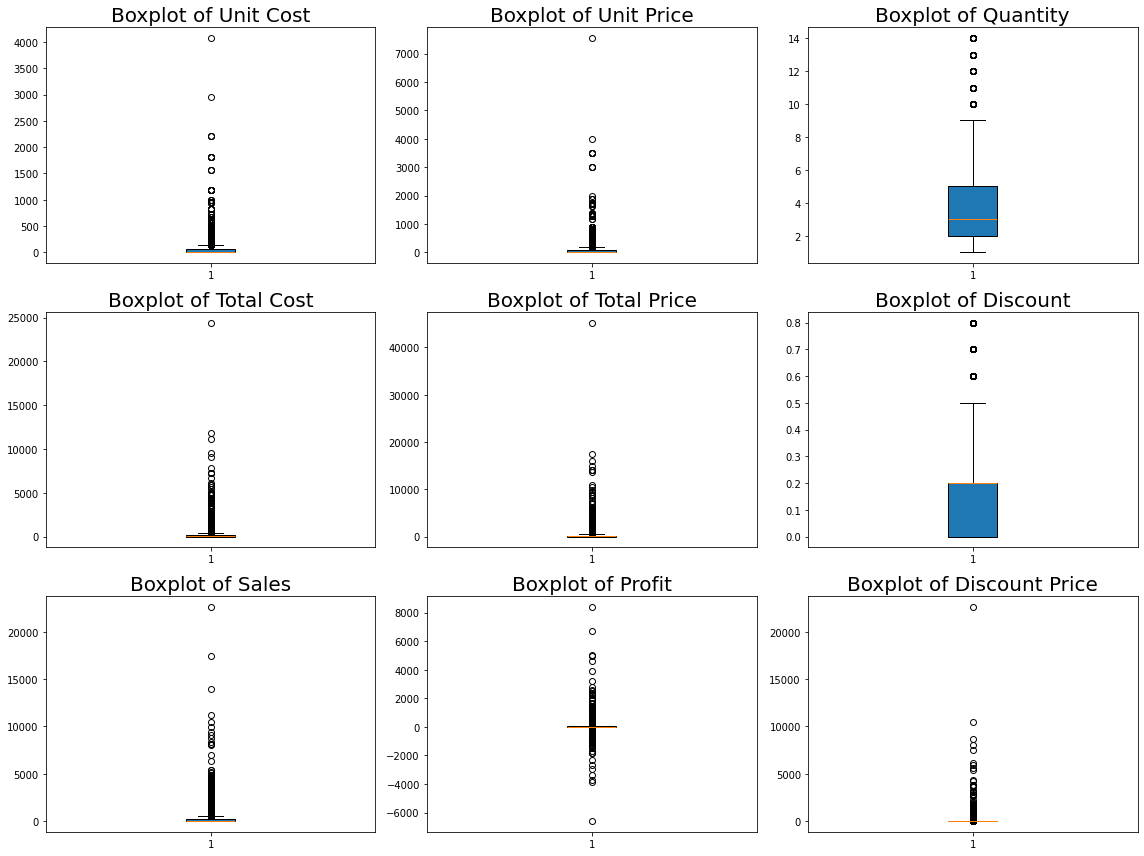

In [9]:
fig, axs = plt.subplots(3, 3,
                        figsize = (16, 12))
axs = axs.flatten()

for i, col_name in enumerate(numerical.columns):
    axs[i].boxplot(df[col_name], vert = True, patch_artist = True)
    axs[i].title.set_text(f'Boxplot of {col_name}')
    axs[i].title.set_fontsize(20)
plt.tight_layout()
plt.show()

**Summary**

**1. Sales:**

* There's a substantial number of outliers in the `Sales` column, indicating high volatility from the typical range of values. This could imply frequent occurrences of extremely high or low sales figures that lie far beyond the expected values within this dataset.

* Most transactions have relatively low sales values, while a few transactions exhibit very high sales values. This distribution is **heavily right skewed** so Sales data is not normal

**2. Quantity:**

* The `Quantity` column has a smaller count of outliers, suggesting instances where the quantity of items ordered might be unusually high or low compared to the usual range of order quantities.

* The majority of transactions involve small purchase quantities, with a few transactions involving significantly large quantities. This distribution also **heavily right skewed** so quantity data is not normal

**3. Discount:**

* All the values might be considered outliers in the `Discount` column since the lower bound is 0 and the upper bound is also 0, indicating that no discounts fall within the typical expected range (assumed discount values are positive).

* Most transactions do not have any discount applied we can see at 0% discount have the highest distribution, and the other are commonly low in applying discount on the their products. Discount data is not normal

**4. Profit:**

* Similar to `Sales`, `Profit` has a considerable number of outliers, indicating instances where the profits earned might significantly high or low from the usual expected profits. There might be a high frequency of both extremely low and high profit margins beyond the defined bounds, take account on the negative profits/loss because the minimum value of `Profit` is negative.

* Profit demonstrates a distribution that is relatively more symmetrical compared to the other columns, but there are still some extreme values present on both sides with kurtosis value > 3 leptokurtic. Profit data is not normal

# Data Analysis and Visualization

## Product Analysis

> **Which products should be eliminated to improve efficiency or reduce inventory, and which products have the potential to further increase profit?**

In [10]:
pivot_product = df.groupby('Product')[['Unit Cost', 'Unit Price', 'Quantity',
                                      'Total Cost', 'Total Price',
                                      'Discount Price', 'Sales', 'Profit']].sum()
pivot_product = pivot_product.round(2)
display(pivot_product)

,Unit Cost,Unit Price,Quantity,Total Cost,Total Price,Discount Price,Sales,Profit
Product,,,,,,,,
Alchemy,25963.12,47999.32,234,93910.21,174847.66,25319.63,149528.03,55617.82
Big Ol Database,48060.50,73744.11,440,185853.87,288085.52,98846.89,189238.63,3384.76
ChatBot Plugin,5338.58,7620.60,3000,20591.00,29394.83,2276.04,27118.79,6527.79
ContactMatcher,102500.93,157422.45,7215,397881.98,609424.62,199046.36,410378.26,12496.28
Data Smasher,31949.08,46092.21,2976,125443.68,179632.82,12252.50,167380.32,41936.64
FinanceHub,81031.29,106572.68,3756,308798.99,407118.20,66182.78,340935.42,32136.42
Marketing Suite,30508.12,38062.85,868,118352.55,148156.55,33276.55,114880.00,-3472.56
Marketing Suite - Gold,54171.91,64414.85,3158,202564.78,240341.07,16497.46,223843.61,21278.83
OneView,23765.31,33734.81,1729,89394.16,126982.58,19450.42,107532.16,18138.01


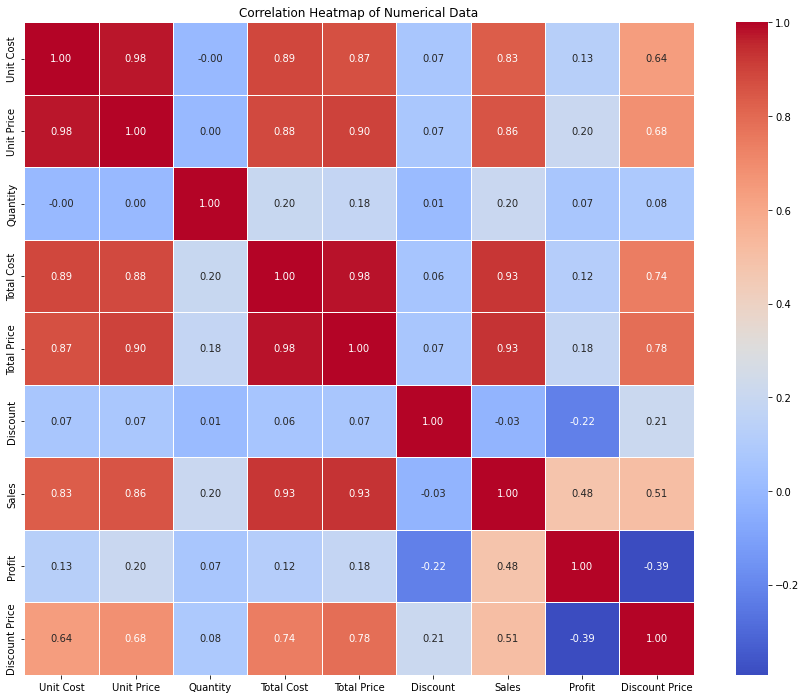

In [47]:
plt.figure(figsize = (15, 12))
sns.heatmap(numerical.corr(), annot = True,
            fmt = ".2f", cmap = 'coolwarm', linewidths = 0.5)
plt.title('Correlation Heatmap of Numerical Data')
plt.show()

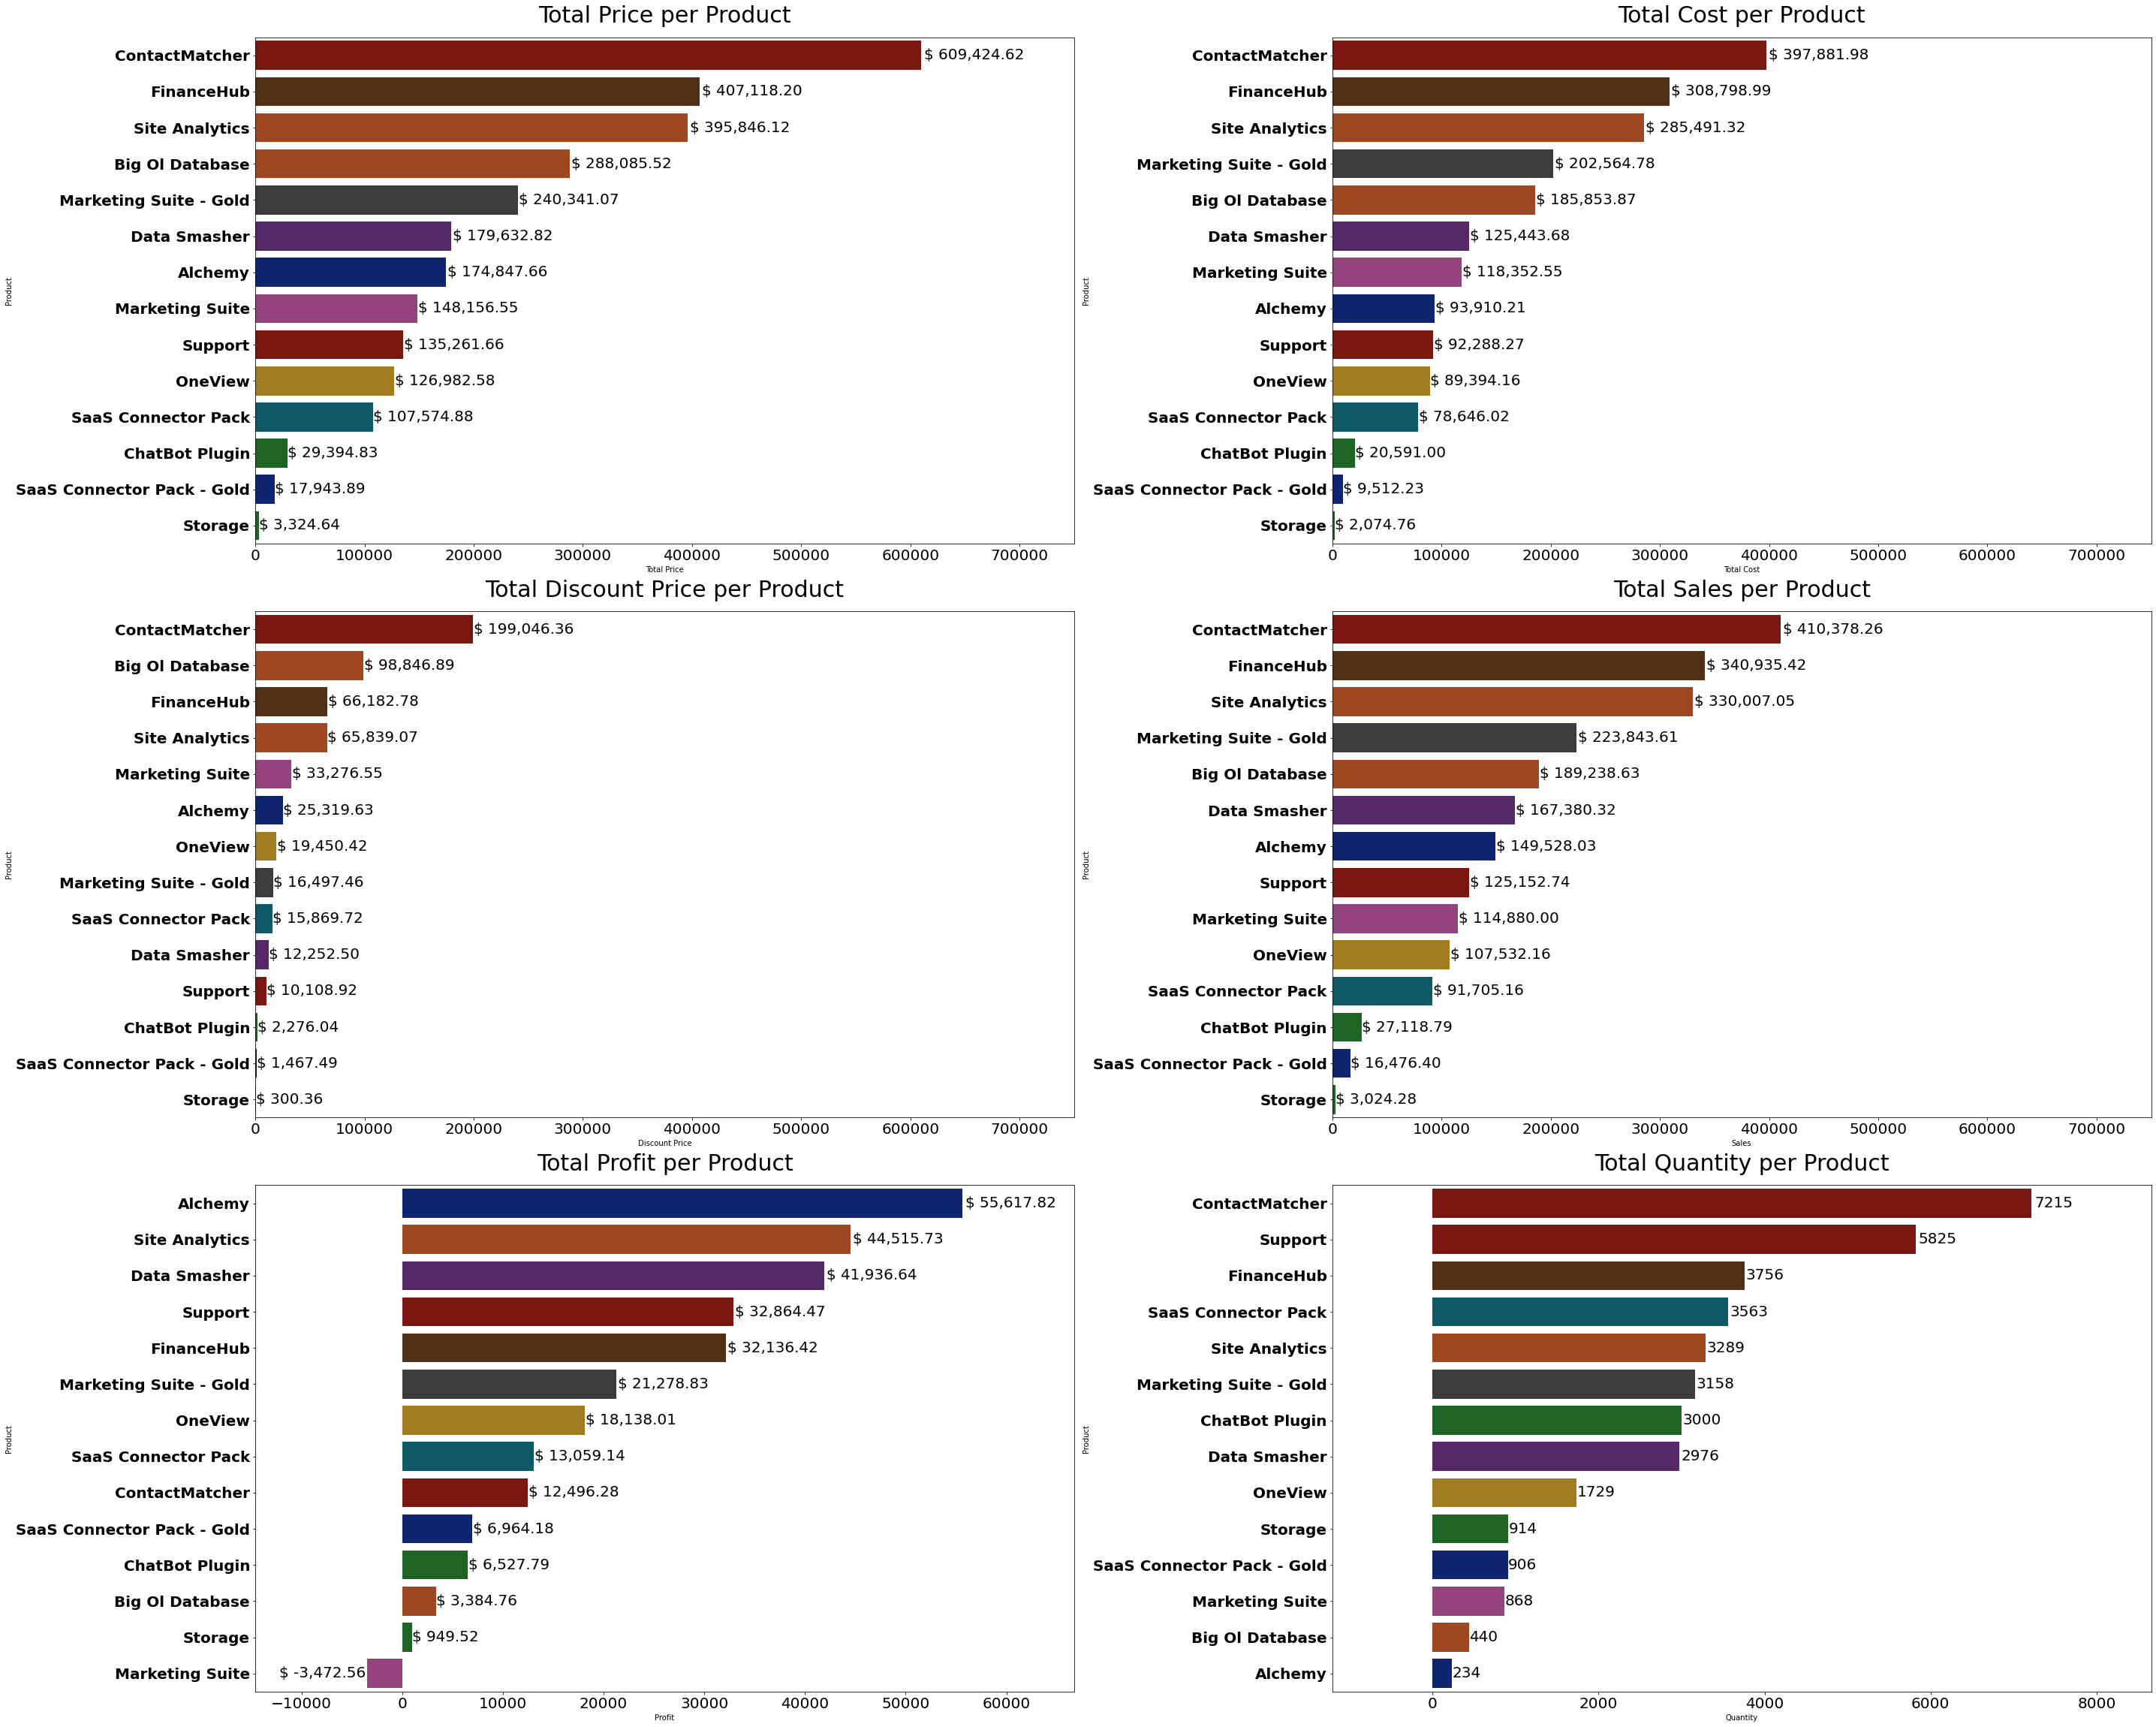

In [67]:
x_columns = ['Total Price', 'Total Cost', 'Discount Price', 
             'Sales', 'Profit', 'Quantity']

products = pivot_product.index.values
colors = sns.color_palette('dark', len(products))
product_colors = dict(zip(products, colors))

if len(x_columns)%2 == 0:
    fig, axs = plt.subplots(len(x_columns)//2, 2, 
                            figsize = (40, 32))
elif len(x_columns%2 != 0):
    fig, axs = plt.subplots(len(x_columns), 1, 
                            figsize = (30, 20))

for ax, x_col in zip(axs.flatten(), x_columns):
    sorted_data = pivot_product.sort_values(by = x_col, 
                                            ascending = False)
    sns.barplot(data = sorted_data, 
                x = x_col, y = 'Product', 
                ci = 0,
               
                # Set the pallete color to keep the colour of each bar stay
                palette = [product_colors[product] for product in sorted_data.index], 
                ax = ax)

    for p in ax.patches:
        value = p.get_width()
        
        # Adding label with % if having 'percent' and $ if not percent
        label = int(value) if 'Quantity' in x_col else f'$ {value:,.2f}'
        
        if value > 0:
            x = p.get_x() + p.get_width() + 0.005 * abs(p.get_width())
            ha = 'left'
        else:
            x = p.get_x() + p.get_width() - 0.01 * len(label) - 0.05 * abs(p.get_width())
            ha = 'right'
            
        ax.annotate(label, (x, p.get_y() + p.get_height() / 2),
                    ha = ha, va = 'center', 
                    fontsize = 20, color = 'black')

    # Add padding after bar_label
    padding = max(abs(p.get_width()) for p in ax.patches) * 0.2
    if (pivot_product[x_col].min() < 0) or ('Quantity' in x_col):
        ax.set_xlim(pivot_product[x_col].min() - padding, pivot_product[x_col].max() + padding)
    elif pivot_product[x_col].min() >= 0:
        # ax.set_xlim(0, pivot_product[x_col].max() + padding)
        ax.set_xlim(0, 750000)
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize = 20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize = 20, weight = 'bold')
    if 'Total' in x_col:
        ax.set_title(f'{x_col} per Product', fontsize = 30, y = 1.02)
    else:
        ax.set_title(f'Total {x_col} per Product', fontsize = 30, y = 1.02)

plt.tight_layout()
plt.show()

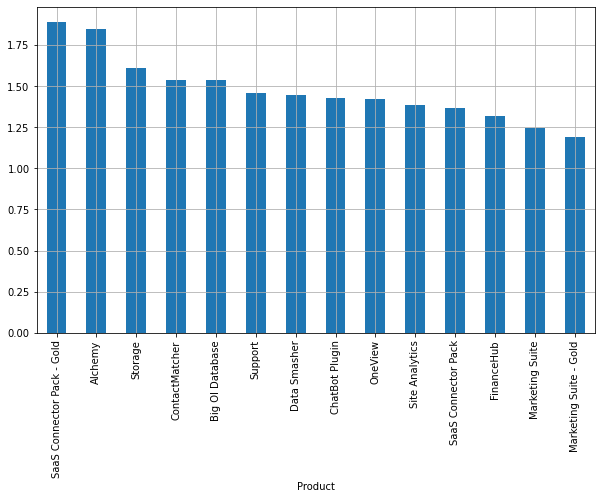

In [81]:
# ratio_total = pivot_product['Total Price']/pivot_product['Total Cost']
ratio_unit = pivot_product['Unit Price']/pivot_product['Unit Cost']

df_ratio = pd.DataFrame(ratio_unit, columns = ['Ratio']).sort_values(by = 'Ratio',
                                                                     ascending = False)
df_ratio.plot(kind = 'bar',
              legend = False,
              figsize = (10, 6),
              grid = True)
plt.show()

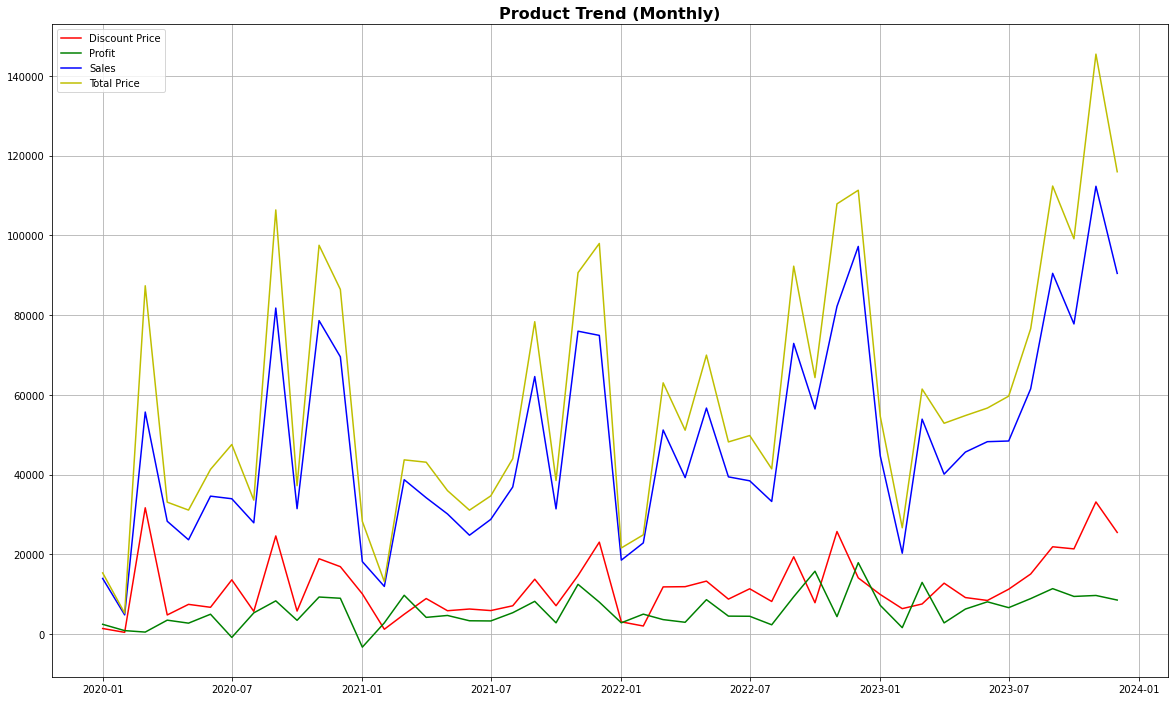

In [29]:
# ['Unit Cost', 'Unit Price', 'Quantity', 'Total Cost', 'Total Price', 'Discount Price', 'Sales', 'Profit']

pivot_profit_sales_trend = pd.pivot_table(data = df,
                                          values = ['Total Price', 'Discount Price', 'Sales', 'Profit'],
                                          index = 'Monthly',
                                          aggfunc = 'sum')
pivot_profit_sales_trend.head(2)

plt.figure(figsize = (20, 12))
for col_name, color in zip(pivot_profit_sales_trend.columns, 'rgbyk'):
    plt.plot(pivot_profit_sales_trend.index,
             pivot_profit_sales_trend[col_name],
             label = col_name,
             color = color)
    
plt.title('Product Trend (Monthly)', 
          weight = 'bold',
          fontsize = 16)
plt.legend()
plt.grid()
plt.show()

In [ ]:
df_profit_sales = df[['Order ID', 'Order Date', 'Country', 'City', 'Region', 'Subregion', 'Industry', 'Segment', 'Product', 'Profit', 'Sales']]
df_profit_sales['Monthly'] = df_profit_sales['Order Date'].dt.to_period('M').dt.to_timestamp()
df_profit_sales.head(2)

pivot_profit_trend = pd.pivot_table(data = df_profit_sales,
                                    values = 'Profit',
                                    index = 'Monthly',
                                    columns = ['Product'],
                                    aggfunc = 'sum').reset_index().fillna(0)
pivot_profit_trend.head()

for col_name in pivot_profit_trend.iloc[:,1:].columns:
    plt.figure(figsize = (10, 6))
    plt.plot(pivot_profit_trend['Monthly'],
             pivot_profit_trend[col_name],
             label = col_name)
    plt.title(f'Profit Trend on {col_name} (Monthly)', weight = 'bold').set_fontsize('16')
# plt.legend()
    plt.grid()
    plt.show()

## Customer Buybacks Analysis

> **Which of the Customer have a high priority for product buybacks to increase the company Sales?**

In [15]:
# Check if a 'Contact Name' handles more than one 'Customer'

for contact in df['Contact Name'].unique():
    check_cust = df[df['Contact Name'] == contact]['Customer'].unique()
    if len(check_cust) > 1:
        print(f'{contact} : {len(check_cust)}')

In [16]:
# Checking the most 'Sales' based on 'Contact Name' per 'Customer'

top_contact_sales_dict = {}
top_order_count_dict = {}

for cust in df['Customer'].unique():
    df_temp = df[df['Customer'] == cust]
    df_contact_temp = pd.pivot_table(data = df_temp,
                                     values = 'Sales',
                                     index = 'Contact Name',
                                     aggfunc = ['sum', 'count'])
    df_contact_temp.columns = df_contact_temp.columns.map('_'.join)
    
    top_contact_sales = df_contact_temp.sum_Sales.idxmax()
    top_order_count = df_contact_temp.count_Sales.idxmax()
    
    top_contact_sales_dict[top_contact_sales] = df_contact_temp.sum_Sales.max()
    top_order_count_dict[top_order_count] = df_contact_temp.count_Sales.max()

In [17]:
df_top_contact_sales = pd.DataFrame(list(top_contact_sales_dict.items()), 
                                    columns=['Contact Name', 'Total Sales']).set_index(
                                        'Contact Name'
                                    ).sort_values(by = 'Total Sales',
                                                  ascending = False)

df_top_order_count = pd.DataFrame(list(top_order_count_dict.items()), 
                                    columns=['Contact Name', 'Total Order']).set_index(
                                        'Contact Name'
                                    ).sort_values(by = 'Total Order',
                                                  ascending = False)

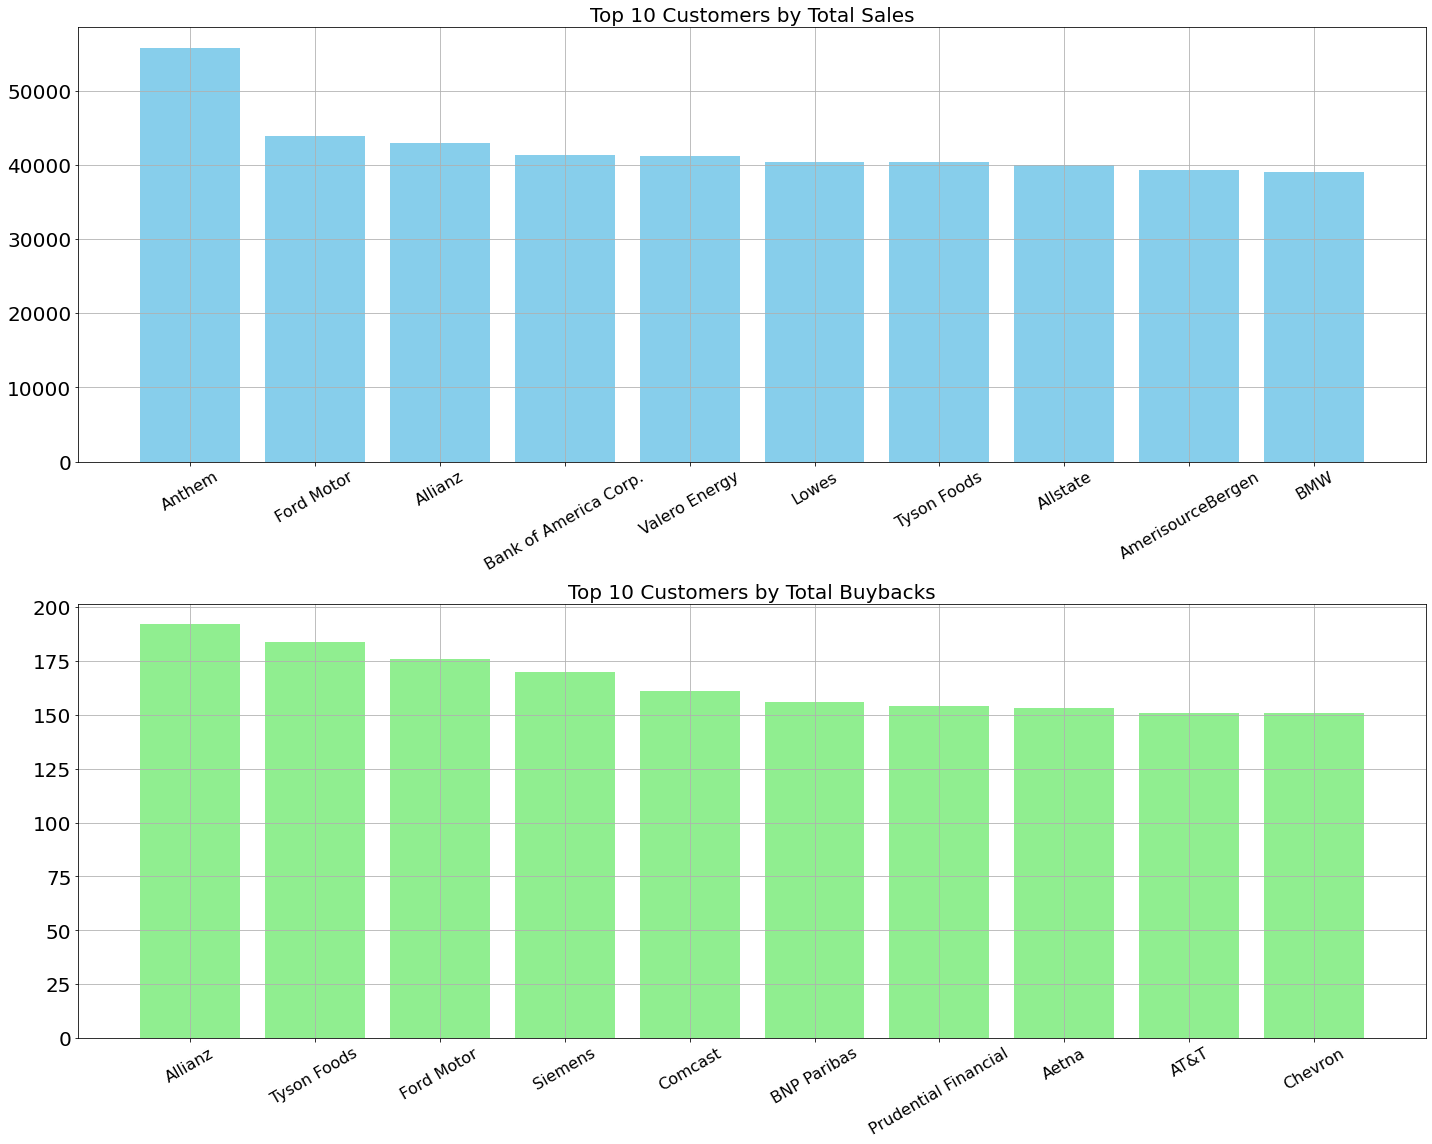

In [42]:
# Checking the most 'Sales' based on 'Customer'

sales_cust_based = pd.pivot_table(data = df,
                                  values = 'Sales',
                                  index = 'Customer',
                                  aggfunc = ['sum', 'count'])
sales_cust_based.columns = sales_cust_based.columns.map('_'.join)

fig, axs = plt.subplots(2, figsize = (20, 16))

top_sum_sales = sales_cust_based.sort_values(by='sum_Sales', ascending=False).head(10)
top_count_sales = sales_cust_based.sort_values(by='count_Sales', ascending=False).head(10)

axs[0].bar(top_sum_sales.index, top_sum_sales['sum_Sales'], color = 'skyblue')
axs[0].tick_params(axis = 'x', rotation = 30, labelsize = 16)
axs[0].tick_params(axis = 'y', labelsize = 20)
axs[0].set_title('Top 10 Customers by Total Sales', fontsize = 20)
axs[0].grid()

axs[1].bar(top_count_sales.index, top_count_sales['count_Sales'], color = 'lightgreen')
axs[1].tick_params(axis = 'x', rotation = 30, labelsize = 16)
axs[1].tick_params(axis = 'y', labelsize = 20)
axs[1].set_title('Top 10 Customers by Total Buybacks', fontsize = 20)
axs[1].grid()
plt.tight_layout()
plt.savefig('Customer_Sales.png', dpi=300, bbox_inches='tight')
plt.show()

## Market Geographical Analysis

In [89]:
pivot_country = pd.pivot_table(data = df,
                               values = ['Sales', 'Quantity', 'Profit'],
                               index = 'Country',
                               aggfunc = 'sum').sort_values(by = 'Profit',
                                                            ascending = False)
display(pd.concat([pivot_country.head(2), pivot_country.tail(2)]).fillna(''))

,Profit,Quantity,Sales
Country,,,
United States,76381.3871,7667,457687.6315
United Kingdom,74989.0891,4268,313169.8810
Mexico,-16971.3766,1759,78258.1360
Japan,-25729.3563,3724,170188.0458


In [90]:
def get_country_coordinates(country_name):
    geolocator = Nominatim(user_agent = 'v9gE0GhUpY4hhQ41LgfxEJND1YATWlPahrp10TbNfovTULA0ukGDKWIsbFqS')
    location = geolocator.geocode(country_name)
    if location:
        return location.latitude, location.longitude
    else:
        None, None

latitude = []
longitude = []
for country in pivot_country.index:
    lat, long = get_country_coordinates(country)
    latitude.append(lat)
    longitude.append(long)

pivot_country['Latitude'] = latitude
pivot_country['Longitude'] = longitude

In [91]:
world_map = folium.Map()

for i in range(len(pivot_country)):
    if pivot_country['Profit'][i] < 0:
        marker_color = 'red'  
    else:
        marker_color = 'blue'  
    
    folium.Marker(
        location = [pivot_country['Latitude'][i], pivot_country['Longitude'][i]],
        popup = f'Country: {pivot_country.index[i]}, Profit: {pivot_country.Profit[i]}',
        tooltip = f'{pivot_country.index[i]}',
        icon = folium.Icon(color = marker_color)  
    ).add_to(world_map)

world_map

## Logistic Quantity Analysis

> How is the trend of product quantity sales across various geographies, as well as the performance of each product's sales quantity, and what are the future prospects for product provisioning?

---

In [26]:
df_logistics = df[['Order ID', 'Order Date', 'Country', 'City', 'Region', 'Subregion', 'Industry', 'Segment', 'Product', 'Quantity']]
df_logistics['Monthly'] = df_logistics['Order Date'].dt.to_period('M')
df_logistics.head(2)

,Order ID,Order Date,Country,City,Region,Subregion,Industry,Segment,Product,Quantity,Monthly
Row ID,,,,,,,,,,,
1,EMEA-2022-152156,2022-11-09,Ireland,Dublin,EMEA,UKIR,Energy,SMB,Marketing Suite,2,2022-11
2,EMEA-2022-152156,2022-11-09,Ireland,Dublin,EMEA,UKIR,Energy,SMB,FinanceHub,3,2022-11


In [27]:
pivot_quantity = pd.pivot_table(data = df_logistics,
                                values = 'Quantity',
                                index = ['Region', 'Subregion', 'Country', 'City'],
                                aggfunc = 'sum').sort_values(
                                    by = 'Quantity'
                                ).reset_index()
pivot_quantity

,Region,Subregion,Country,City,Quantity
0,AMER,NAMER,Canada,Victoria,1
1,AMER,NAMER,United States,Alexandria,2
2,AMER,NAMER,United States,Huntsville,3
3,AMER,NAMER,United States,Tucson,3
4,AMER,NAMER,United States,Tampa,3
...,...,...,...,...,...
257,AMER,NAMER,Canada,Toronto,1600
258,AMER,NAMER,United States,Los Angeles,1935
259,EMEA,EU-WEST,France,Paris,1981
260,AMER,NAMER,United States,New York City,2842


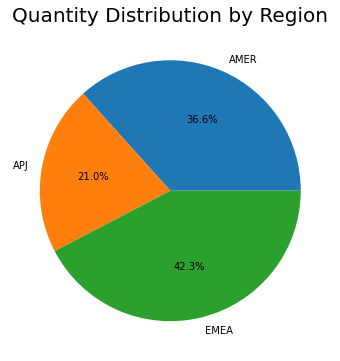

In [28]:
# Quantity Distribution on Region

quantity_region = pivot_quantity.groupby('Region')[['Quantity']].sum()

plt.figure(figsize = (10, 6), facecolor = 'white')
plt.pie(quantity_region.Quantity, 
        labels = quantity_region.index,
        autopct = '%.1f%%')
plt.title('Quantity Distribution by Region', fontsize = 20)
plt.show()

,Quantity
Subregion,
JAPN,3724
LATAM,4329
UKIR,4747
EU-WEST,6070
NAMER,9550


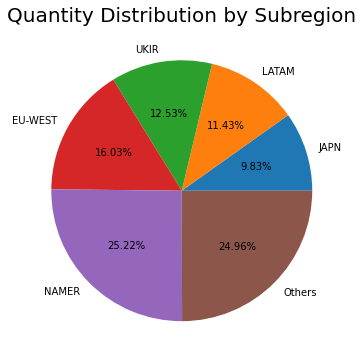

In [29]:
# Quantity Distribution on Subregion

quantity_subregion = pivot_quantity.groupby('Subregion')[['Quantity']].sum()
quantity_subregion.sort_values(by = 'Quantity', inplace = True)
display(quantity_subregion.tail(5))

# Group Subregions to 'Others'
subregions_to_group = ['EU', 'IND', 'EU-EAST', 'MEA', 'APAC', 'NOR', 'ANZ']
others_quantity = quantity_subregion.loc[subregions_to_group, 'Quantity'].sum()
quantity_subregion.loc['Others'] = others_quantity
quantity_subregion.drop(subregions_to_group, inplace = True)

plt.figure(figsize = (10, 6), facecolor = 'white')
plt.pie(quantity_subregion.Quantity, 
        labels = quantity_subregion.index,
        autopct = '%.2f%%')
plt.title('Quantity Distribution by Subregion', fontsize = 20)
plt.show()

In [28]:
pd.pivot_table(data = df,
           values = 'Quantity',
           index = ['Region', 'Subregion'],
           aggfunc = 'sum')

Quantity
Region Subregion          
AMER   LATAM          4329
       NAMER          9550
APJ    ANZ            1996
       APAC           1663
       IND             578
       JAPN           3724
EMEA   EU              463
       EU-EAST        1365
       EU-WEST        6070
       MEA            1501
       NOR            1887
       UKIR           4747

In [30]:
quantity_country = pd.pivot_table(data = pivot_quantity,
                                  values = 'Quantity',
                                  index = ['Region', 'Country'],
                                  aggfunc = 'sum').sort_values(
                                      by = 'Quantity', ascending = False
                                  )
# quantity_country.index = quantity_country.index.map(' - '.join)
quantity_country.head()

,,Quantity
Region,Country,
AMER,United States,7667
EMEA,United Kingdom,4268
APJ,Japan,3724
EMEA,France,2153
AMER,Canada,1883


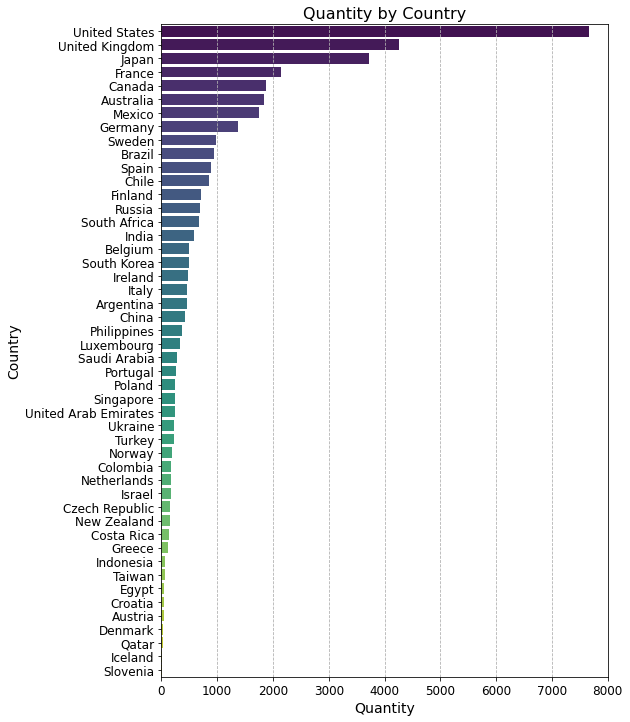

In [31]:
# Quantity Distribution on Country

quantity_country = pd.pivot_table(data = pivot_quantity,
                                  values = ['Quantity'],
                                  index = ['Country'],
                                  aggfunc = 'sum').sort_values(
                                      by = 'Quantity', ascending = False
                                  )
quantity_country

plt.figure(figsize = (8, 12))
sns.barplot(data = quantity_country, 
            x = 'Quantity', y = quantity_country.index, 
            palette = 'viridis')
plt.title('Quantity by Country', fontsize=16)
plt.xlabel('Quantity', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlim(0, 8000)
plt.grid(axis='x', linestyle='--')
plt.show()

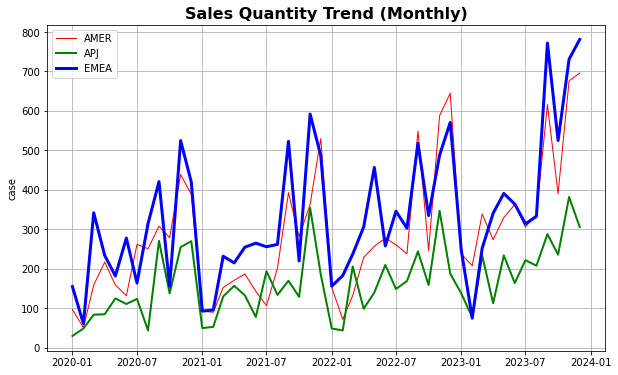

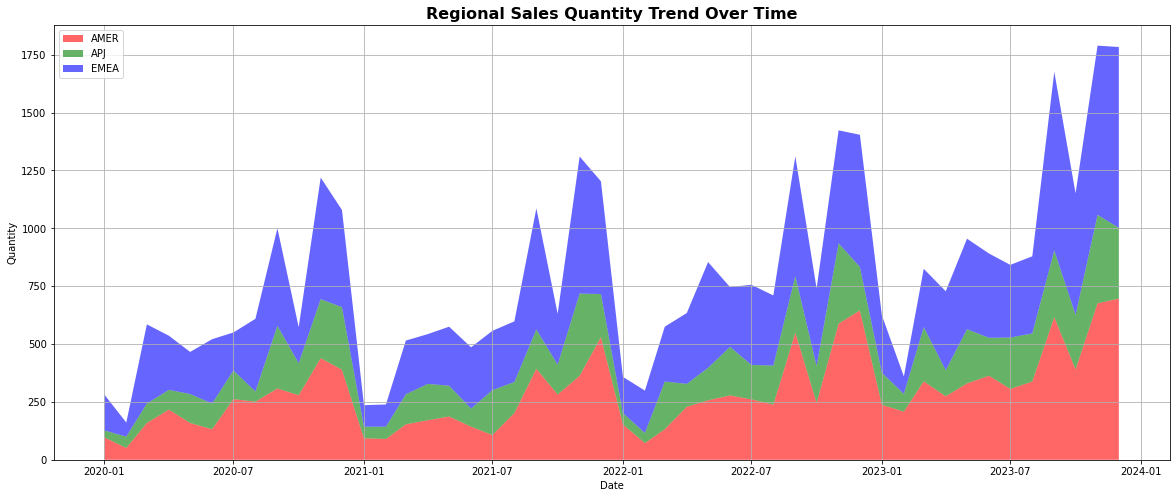

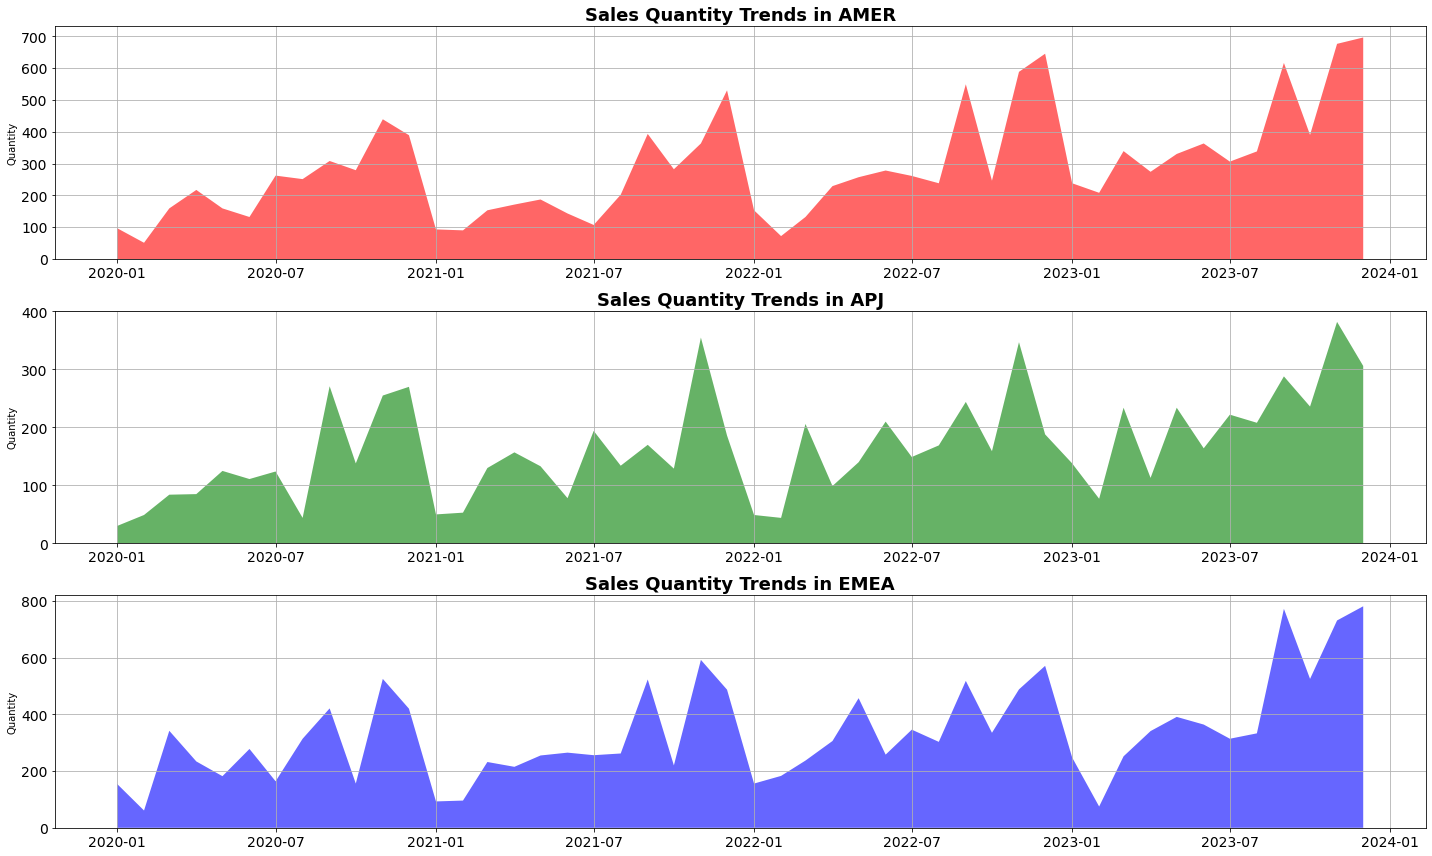

In [32]:
# Quantity Area Chart based on Region

pivot_quantity_trend = pd.pivot_table(data = df_logistics,
                                      values = 'Quantity',
                                      index = 'Monthly',
                                      columns = 'Region',
                                      aggfunc = 'sum').reset_index()
pivot_quantity_trend['Monthly'] = pivot_quantity_trend['Monthly'].dt.to_timestamp()

# Line Chart
plt.figure(figsize = (10, 6))
for col_name, line, color in zip(['AMER', 'APJ', 'EMEA'], range(1, 4), 'rgb'):
    plt.plot(pivot_quantity_trend['Monthly'],
             pivot_quantity_trend[col_name],
             lw = line,
             color = color,
             label = col_name)
# pivot_quantity_trend.plot('Monthly', ['AMER', 'APJ', 'EMEA'], 
#                           figsize = (20, 8),
#                           lw = 3,
#                           color = ['r', 'g', 'b'])
plt.title('Sales Quantity Trend (Monthly)', weight = 'bold').set_fontsize('16')
plt.ylabel('case')
plt.legend()
plt.grid()
plt.show()

# Area Chart
plt.figure(figsize = (20, 8))
plt.stackplot(pivot_quantity_trend['Monthly'],
              *[pivot_quantity_trend[region] for region in ['AMER', 'APJ', 'EMEA']],
              labels = pivot_quantity_trend.iloc[:,1:].columns,
              colors = ['r', 'g', 'b'],
              alpha = 0.6)
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.title('Regional Sales Quantity Trend Over Time', 
          weight = 'bold').set_fontsize('16')
plt.legend(loc = 'upper left')
plt.grid(True)
plt.show()

fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (20, 12), sharex = False)

for idx, (region, color) in enumerate(zip(['AMER', 'APJ', 'EMEA'], ['r', 'g', 'b'])):
    axs[idx].stackplot(pivot_quantity_trend['Monthly'],
                        pivot_quantity_trend[region],
                        labels = [region],
                        colors = color,
                        alpha = 0.6,)
    axs[idx].set_ylabel('Quantity')
    axs[idx].set_title(f'Sales Quantity Trends in {region}', 
                       fontsize = 18, weight = 'bold')
    axs[idx].tick_params(axis = 'x', labelsize = 14)
    axs[idx].tick_params(axis = 'y', labelsize = 14)
    axs[idx].grid(True)

plt.tight_layout()
plt.show()

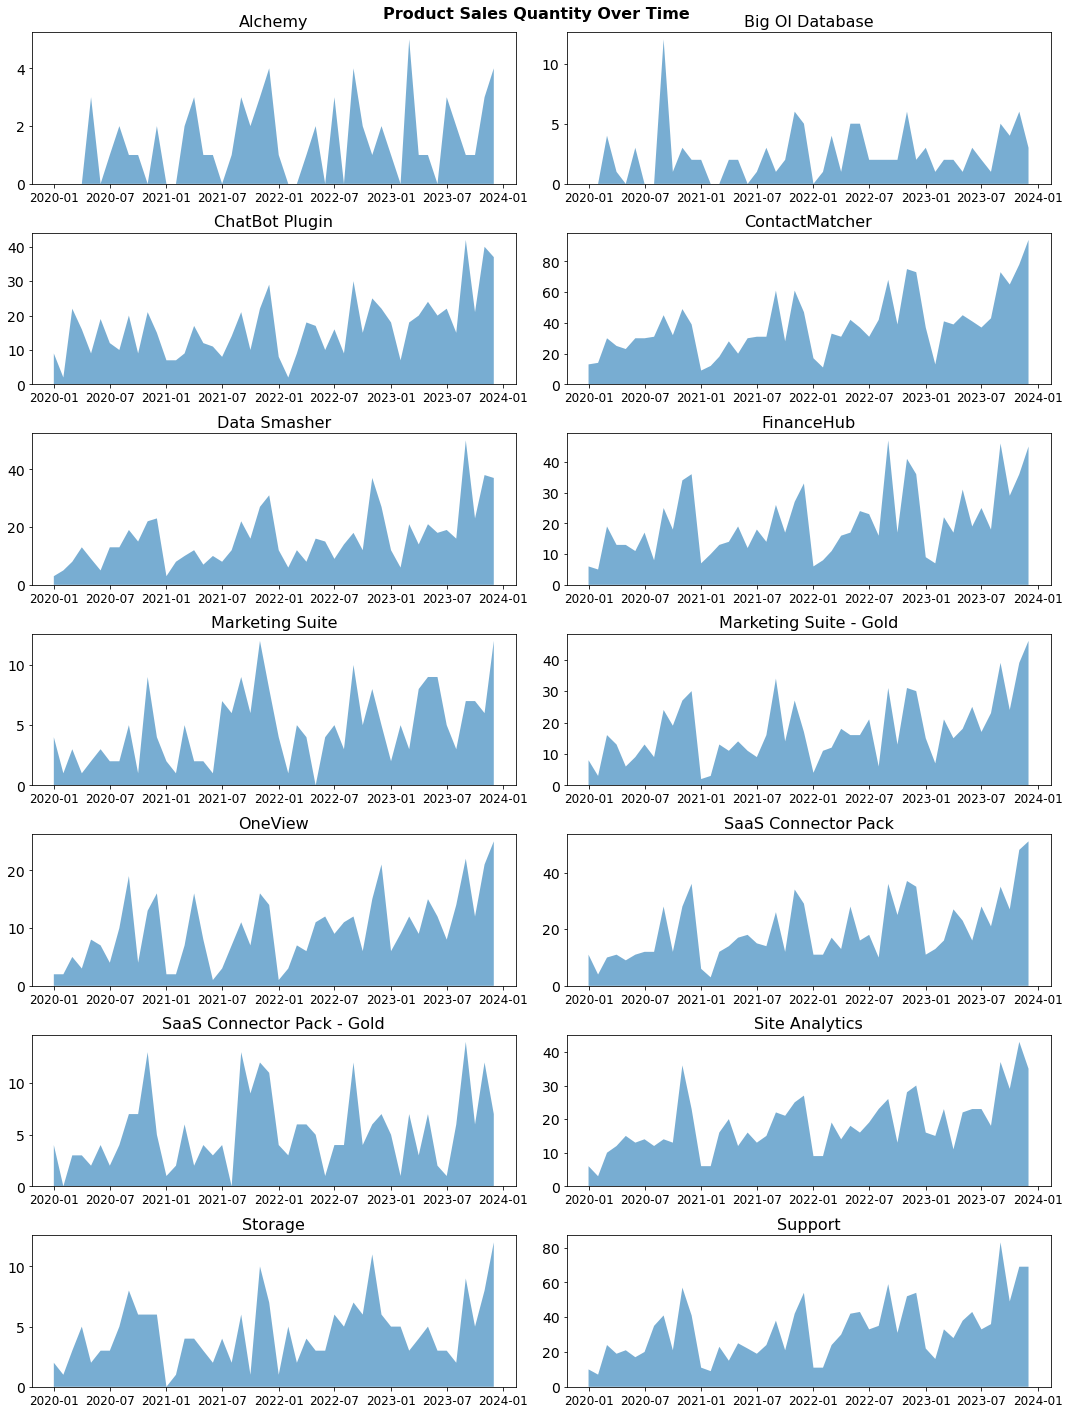

In [33]:
pivot_quantity_trend = pd.pivot_table(data = df_logistics,
                                      values = 'Quantity',
                                      index = 'Monthly',
                                      columns = ['Product'],
                                      aggfunc = 'count').reset_index().fillna(0)
pivot_quantity_trend['Monthly'] = pivot_quantity_trend['Monthly'].dt.to_timestamp()

products = pivot_quantity_trend.iloc[:,1:].columns

fig, axes = plt.subplots(nrows = 7, ncols = 2, figsize=(15, 20))
axes = axes.flatten()

for i, product in enumerate(products):
    axes[i].stackplot(pivot_quantity_trend['Monthly'], 
                      pivot_quantity_trend[product], 
                      labels = [product], 
                      alpha = 0.6)
    axes[i].set_title(product, fontsize = 16)
    axes[i].tick_params(axis = 'x', labelsize=12)
    axes[i].tick_params(axis = 'y', labelsize=14)

plt.suptitle('Product Sales Quantity Over Time', fontsize = 16, weight = 'bold')
plt.tight_layout()
plt.show()

In [34]:
top_logistic_country = quantity_country.reset_index()
top_logistic_country = top_logistic_country[top_logistic_country.Quantity >= 1000]
top_logistic_country

,Country,Quantity
0,United States,7667
1,United Kingdom,4268
2,Japan,3724
3,France,2153
4,Canada,1883
5,Australia,1845
6,Mexico,1759
7,Germany,1379
